# Optimization

#### Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import sys
import os

# Add the parent directory (or another appropriate path) to sys.path so Python can find Exclusion_functions
notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
function_dir = os.path.abspath(os.path.join(parent_dir, 'Function_Files'))
if function_dir not in sys.path:
    sys.path.append(function_dir)

import pandas as pd
import datetime
import numpy as np

import Exclusion_functions as ef
import Optimization_functions as of
import Final_report_functions as frf

In [ ]:
CATEGORY = "Cutlery"
TODAY = datetime.datetime.now().strftime('%m.%d.%Y')
IP_PATH = f"{parent_dir}\\Data\\"
IP_PATH_CAT = f"{parent_dir}\\Data\\{CATEGORY}\\"
OP_PATH = f"{parent_dir}\\Data\\{CATEGORY}\\Output\\"

In [76]:
# read back in group transactions from Taxonomy step
cat_data_final = pd.read_csv(f"{OP_PATH}{CATEGORY}_matches.csv")
transactions = pd.read_csv(f"{OP_PATH}Cutlery Data - Cleaned.csv")

C:\Users\zwayne\AppData\Local\Temp\ipykernel_52472\3391324984.py:3: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv(f"{OP_PATH}Cutlery Data - Cleaned.csv")


#### Get Exclusions

In [ ]:
# Merge matches onto transactions
transactions_merged = transactions.merge(
    cat_data_final[["Entity--Item", "Matches"]],
    on="Entity--Item",
    how="left"
)

# Define the aggregation dictionary.
agg_dict = {
    "Qty": "sum",
    "Net Cost": "sum",
    "Gross Cost": "sum",
    "Matches": "first",
    "VGN": "first",
    "Customer Class": "first",
    "Price Group Name": "first",
    "Case Pack": "mean",
}


transactions_merged["Case Pack"] = pd.to_numeric(transactions_merged["Case Pack"], errors="coerce")

# Group by item/customer and aggregat
transactions_grouped_by_item_customer = (
    transactions_merged
    .groupby(["Entity--Item", "Customer Code"], dropna=False)
    .agg(agg_dict)
    .rename(columns={
        "Qty": "Total_Qty",
        "Net Cost": "Total_Net_Cogs",
        "Gross Cost": "Total_Gross_Cost",
        "Price Group Name": "Customer_Name",
    })
    .reset_index()
)

In [ ]:
# I have a vendor exclusion sheet from ID team that I am reading in and labeling any item from one of these vendors for exclusion
# I also add in VB Vendors because excluded Vendors = Do Not Swap Away - which we want for PL Vendors
vendor_exclusions = pd.read_excel(f"{IP_PATH}Customer and Vendor Exclusions.xlsx", sheet_name="VGN Table list", skiprows=2)
vendor_exclusions = set(vendor_exclusions[vendor_exclusions['Nonaddressable'] == 'X']['VGN'].tolist())
vendor_exclusions = vendor_exclusions.union(['Direct Link','Carryout Bags, Inc.'])
vendor_exclusions = cat_data_final[cat_data_final['VGN'].isin(vendor_exclusions)]['Entity--Item'].unique().tolist()
print(f"Found {len(vendor_exclusions)} unqiue SKUS bought by excluded vendors")

Found 555 unqiue SKUS bought by excluded vendors


In [ ]:
# I have a Customer exclusion sheet from ID team that I am reading in and labeling any item that goes to one of these Customer for exclusion
customer_exclusions = pd.read_excel(f"{IP_PATH}Customer and Vendor Exclusions.xlsx", sheet_name="Customer Table list", skiprows=2)
customer_exclusions = set(customer_exclusions[customer_exclusions['Nonaddressable'] == 'X']['Customer Name'].tolist())
get_skus_to_excl_cust = ef.get_skus_to_excl_cust(transactions_grouped_by_item_customer, customer_exclusions)
customer_exclusions_skus = get_skus_to_excl_cust['Entity--Item'].unique().tolist()

In [ ]:
# Any item that goes to a redistributor is excluded
redi = ef.get_skus_to_redi(transactions_grouped_by_item_customer)
redi_skus = redi['Entity--Item'].unique().tolist()

Found 1042 unique SKUs serving redi customers


In [10]:
must_keep_ids = list(set(vendor_exclusions + redi_skus + customer_exclusions_skus)); len(must_keep_ids)

2064

In [ ]:
# read in rebates file from ID - create cost_diff matrix
# this matrix is made using my understanding of the cost analyis process - complete with adjusting for case pack and taking into account POD/Non-POD
# the resulting matrix cell i, j is the cost saved by swapping from item i to item j
rebates = pd.read_excel(f"{IP_PATH}\\Rebates.xlsx")
cost_diff_df = of.get_cost_diff_df(cat_data_final, transactions, rebates)

#### Loop through optimization

In [ ]:
# here i loop through an optimization
# the optimization logic is highlighed in the slides
# but essentially I am lowering the amount of vendors i am allowing till the problem becomes infeasible (i.e. I can't swap all items to 1 vendor for example)
results = of.solve_swap_optimization_looped(cat_data_final, cost_diff_df, must_keep_ids)

--- Initializing Looped Optimization Problem ---
Starting optimization loop. Initial max suppliers: 224

--- Solving for Max Suppliers <= 224 ---
--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $1,908,275.73
Number of swaps: 1185
Active suppliers: 202

--- Solving for Max Suppliers <= 212 ---
--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $1,908,275.73
Number of swaps: 1186
Active suppliers: 201

--- Solving for Max Suppliers <= 201 ---
--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $1,908,275.73
Number of swaps: 1186
Active suppliers: 201

--- Solving for Max Suppliers <= 190 ---
--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $1,904,785.79
Number of swaps: 1198
Active suppliers: 190

--- Solving for Max

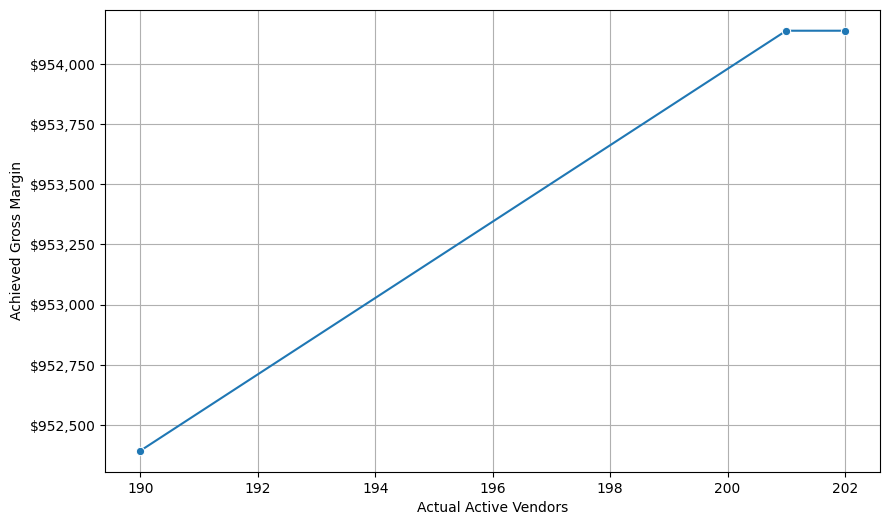

In [ ]:
# this graphs the Achieved_Cost_Savings by Actual_Active_Suppliers
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=results, x='Actual_Active_Suppliers', y='Achieved_Cost_Savings', marker='o')
plt.xlabel('Actual Active Vendors')
plt.ylabel('Achieved Cost Savings')
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.grid()
plt.show()


#### Run best optimization and update df

In [ ]:
max_suppliers_limit = 201
# I set the max_suppliers_limit based on the elbow of the graph above, the data I have is L6M so I scale savings by 2 to get yearly
results = of.solve_swap_optimization(cat_data_final, cost_diff_df, must_keep_ids, max_suppliers = max_suppliers_limit)

--- Initializing Swap Optimization Problem ---
--- Optimization Results ---
Status: Optimal
Total yearly cost savings: $1,908,275.73
Number of swaps: 1186
Active suppliers: 201


In [43]:
updated_df = of.analyze_swap_results(cat_data_final, results)

In [36]:
print("Current Number of SKUs:", len(updated_df['Entity--Item'].unique()))
print("New Number of SKUs:", len(updated_df[updated_df['Final_Volume'] > 0.1]['Entity--Item'].unique()))
print("\n")
print("Volume the Same? ", updated_df['Original_Volume'].sum() == updated_df['Final_Volume'].sum())
print("\n")
print("Current Vendors:", len(updated_df['Original_Supplier'].unique()))
print("New Vendors:", len(updated_df['New_Supplier'].unique()))
print("\n")

print(f"Current Net Cost: ${updated_df['Original_Cost'].sum()*2 :,.2f}")
print(f"New Net Cost:     ${updated_df['Original_Cost'].sum()*2-updated_df['Savings_From_Swapping_Away'].sum()*2 :,.2f}")
print(f"Cost Savings:     ${updated_df['Savings_From_Swapping_Away'].sum()*2:,.2f}")

Current Number of SKUs: 4717
New Number of SKUs: 3531


Volume the Same?  True


Current Vendors: 225
New Vendors: 201


Current Net Cost: $75,233,618.00
New Net Cost:     $73,325,342.27
Cost Savings:     $1,908,275.73


In [37]:
feedback_file = pd.read_csv(f"{OP_PATH}{CATEGORY}_feedback_df.csv")

In [ ]:
# create an enhanced report that I would send a CM with the optimal swaps
frf.create_enhanced_sku_report(updated_df, feedback_file, transactions_grouped_by_item_customer,  f"{OP_PATH}{CATEGORY}_Final_Report_{TODAY}.xlsx" , customer_exclusions = get_skus_to_excl_cust['Customer Code'].unique().tolist(), redi_customers= redi['Customer Code'].unique().tolist())

--- Starting to generate Enhanced SKU Report: c:\Users\zwayne\OneDrive - Advent International\Documents\GitHub\ImperialDadeCategoryManagement\Data\Cutlery\Output\Cutlery_Final_Report_09.08.2025.xlsx ---

--- Processing Sheet: Suggested Swaps ---

--- Processing Sheet: Vendor Performance Summary ---

--- Processing Sheet: Customer Performance Summary ---
--- Successfully created Enhanced SKU Report: c:\Users\zwayne\OneDrive - Advent International\Documents\GitHub\ImperialDadeCategoryManagement\Data\Cutlery\Output\Cutlery_Final_Report_09.08.2025.xlsx ---


True

# Optimization Feedback
if any feedback from the optimization, you can load in here. These two cells/functions will remove the Rejects from the matches, then you can rerun the optimization

In [67]:
suggested_swaps_df = frf.read_and_process_feedback_excel( f"{OP_PATH}Cutlery_Final_Report_09.08.2025.xlsx")

--- Reading feedback from Excel file: c:\Users\zwayne\OneDrive - Advent International\Documents\GitHub\ImperialDadeCategoryManagement\Data\Cutlery\Output\Cutlery_Final_Report_09.08.2025.xlsx ---
Processing sheet: Suggested Swaps...
Successfully extracted data from 'Suggested Swaps'. Found 1186 rows.


In [68]:
cat_data_final = frf.incorporate_swaps_feedback(cat_data_final, suggested_swaps_df)

## Go back and rerun optimization